# Runtime outliers — what the slow Mesa runs actually did

**Thesis.** At this problem scale the Mesa arm is *usually faster* than Josh
(median sim-wall **78 s** vs **210 s**). But Mesa is unconstrained imperative
Python: nothing stops an agent from writing an accidental performance disaster,
and a handful did — blowing up to 10–45 minutes. The Josh arm can't express
those footguns. Climate data is **bound declaratively** by the DSL, so the
dominant failure mode below — *re-reading / re-scanning the climate grid inside
an inner loop* — is simply not a program you can write in Josh.

This notebook walks every Mesa run slower than the **josh median** and shows the
actual offending source (read straight from the saved workspace), grouped by root
cause:

1. **Data-access pathologies** (7 runs) — global work redone in an inner loop. *The mess Josh prevents.*
2. **Over-engineered arithmetic** (2 runs) — correct, but far more Decimal work than the task needs.
3. **Legitimately heavy** (2 runs) — no pathology, just scale.

> `Decimal` arithmetic is **mandated** by the mesa prompt (`prompts/targets/mesa.md`
> §Numerical precision), so using it is never the defect — only *over*-specifying
> it (Bucket 2) is. Source of truth: `analysis/aggregated.csv` + the per-cell
> workspaces under `runs/`. Per-run diagnoses were produced by subagents reading
> each workspace; the quoted line ranges are verified against the source.

In [1]:
import os, glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Resolve paths whether run from analysis/ (pixi run lab) or the repo root.
AGG = next(f for f in ["aggregated.csv", "analysis/aggregated.csv"] if os.path.exists(f))
RUNS_DIR = next(d for d in ["runs", "../runs"] if os.path.isdir(d))
OUT_DIR = "figures" if os.path.isdir("figures") or not os.path.isdir("analysis") else "analysis/figures"
os.makedirs(OUT_DIR, exist_ok=True)
for _f in glob.glob("fonts/*.ttf") + glob.glob("analysis/fonts/*.ttf"):
    try: font_manager.fontManager.addfont(_f)
    except Exception: pass
try: plt.rcParams["font.family"] = "Lato"
except Exception: pass
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv(AGG)
META = df.set_index("run_id")
ran = df[df["sim_wall_seconds"].notna()]

def show(run_path, fname, a, b):
    # Cat lines a..b of a saved workspace file, header pulled from the data.
    run_id = os.path.basename(run_path)
    sec = META.loc[run_id, "sim_wall_seconds"]
    ok  = META.loc[run_id, "substantive_conformance"]
    p = os.path.join(RUNS_DIR, run_path, "workspace", fname)
    lines = Path(p).read_text().splitlines()
    print(f"{run_id}")
    print(f"  sim_wall = {sec:.0f}s   conformance = {'PASS' if ok else 'FAIL'}   ({fname}:{a}-{b})")
    print("  " + "-"*72)
    for i in range(a-1, min(b, len(lines))):
        print(f"  {i+1:4d} | {lines[i]}")

## Mesa is faster at the median — with a long right tail

The median is the headline (Mesa fastest); the **max** is the outlier story.

,n,median,p90,max
target,,,,
mesa,72,78.2,299.7,2708.7
josh,72,209.9,287.4,539.5
josh-mcp,72,191.8,341.5,423.6



mesa median 78s is 2.7x faster than josh median 210s — but mesa's slowest run is 5.0x josh's slowest.


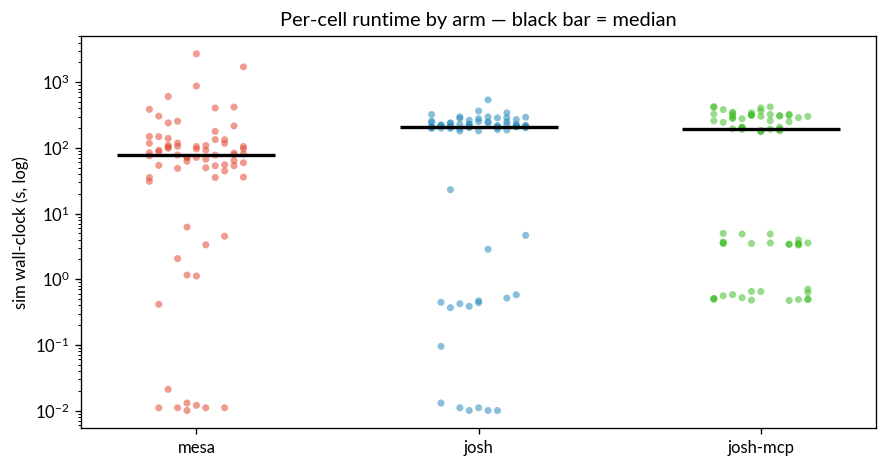

In [2]:
summary = (ran.groupby("target")["sim_wall_seconds"]
              .agg(n="count", median="median", p90=lambda s: s.quantile(.9), max="max")
              .round(1).reindex(["mesa","josh","josh-mcp"]))
JOSH_MED = summary.loc["josh","median"]; MESA_MED = summary.loc["mesa","median"]
display(summary)
print(f"\nmesa median {MESA_MED:.0f}s is {JOSH_MED/MESA_MED:.1f}x faster than josh median {JOSH_MED:.0f}s — "
      f"but mesa's slowest run is {summary.loc['mesa','max']/summary.loc['josh','max']:.1f}x josh's slowest.")

TARGET_COLORS = {"mesa":"#e34a33","josh":"#2b8cbe","josh-mcp":"#43be2b"}
fig, ax = plt.subplots(figsize=(7.5, 4))
for i, t in enumerate(["mesa","josh","josh-mcp"]):
    s = ran.loc[ran["target"]==t, "sim_wall_seconds"]
    ax.scatter([i+(h%11-5)/30 for h in range(len(s))], s, s=18, alpha=.55,
               color=TARGET_COLORS[t], edgecolor="none")
    ax.hlines(s.median(), i-.28, i+.28, color="black", lw=2, zorder=5)
ax.set_yscale("log"); ax.set_xticks(range(3)); ax.set_xticklabels(["mesa","josh","josh-mcp"])
ax.set_ylabel("sim wall-clock (s, log)"); ax.set_title("Per-cell runtime by arm — black bar = median")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/runtime_dist.png", bbox_inches="tight")
fig.savefig(f"{OUT_DIR}/runtime_dist.pdf", bbox_inches="tight"); plt.show()

## Bucket 1 — Data-access pathologies: the mess Josh structurally can't express

Seven of the eleven slow runs share one shape: **the climate grid is re-read or re-scanned inside an inner loop** (per patch, per tree, or per timestep), re-doing global work that depends only on (patch, year). In Mesa this is just imperative Python an agent can write without noticing. In Josh the climate inputs are **bound declaratively** — there is no place to write "read the whole file again this tick," so the entire class of bug below is unreachable by construction. (Each ran to a correct answer except where noted — they were slow, not wrong.)

### minimax — lazy xarray re-read from disk, every patch every tick

The two climate datasets are opened with `xr.open_dataset(...)` but never `.load()`-ed, so they stay lazy, backed by the NetCDF files on disk. `_get_climate_for_patch` then indexes `…["tasmax"].values[y, la, lo]` — and on a lazy array, `.values` materializes the **entire** variable from disk before pulling out one scalar. The method runs once per patch per year (1 470 patches × 100 yr × 100 replicates ≈ 14.7M calls), so the whole climate cube is re-read millions of times. A single `.load()` at startup would make it trivial; nothing in Mesa required the agent to think of it.

In [3]:
show('headline-stage1-20260601/headline-stage1-20260601-minimax-mesa-r1', 'model.py', 106, 117)

headline-stage1-20260601-minimax-mesa-r1
  sim_wall = 2709s   conformance = PASS   (model.py:106-117)
  ------------------------------------------------------------------------
   106 |     def _get_climate_for_patch(self, patch):
   107 |         lat_frac = (patch.pos[1] + 0.5) / self.n_lat
   108 |         lon_frac = (patch.pos[0] + 0.5) / self.n_lon
   109 |         lat_idx = min(self.NATIVE_LAT_SIZE - 1, int(lat_frac * self.NATIVE_LAT_SIZE))
   110 |         lon_idx = min(self.NATIVE_LON_SIZE - 1, int(lon_frac * self.NATIVE_LON_SIZE))
   111 | 
   112 |         year_idx = self.step_count
   113 |         temperature = float(self.tasmax_ds["tasmax"].values[year_idx, lat_idx, lon_idx])
   114 |         precip_raw = float(self.precip_ds["pr"].values[year_idx, lat_idx, lon_idx])
   115 |         precipitation = precip_raw * float(SECONDS_PER_YEAR)
   116 | 
   117 |         return temperature, precipitation


### nemotron — linear DataFrame scan per agent-step

Climate is correctly pre-extracted per year into small DataFrames — but then `get_patch_climate` looks a patch up with a full boolean mask `(df['position.x']==x) & (df['position.y']==y)` and `.iloc[0]`, a linear scan of the year's frame on **every** lookup. Called per agent-step plus per stats-collection (~6M times), the repeated O(n) scan dominates, even though each frame is tiny. A dict keyed by `(x, y)` would make it O(1).

In [4]:
show('fill-202606032041/fill-202606032041-nemotron-mesa-r2', 'forevertree.py', 110, 120)

fill-202606032041-nemotron-mesa-r2
  sim_wall = 1714s   conformance = PASS   (forevertree.py:110-120)
  ------------------------------------------------------------------------
   110 |     def get_patch_climate(self, x, y, year):
   111 |         """Get temperature and precipitation for a patch at a given year."""
   112 |         # climate_data[year] is a DataFrame with columns: position.x, position.y, temperature, precipitation
   113 |         # We'll filter for the patch
   114 |         df_year = self.climate_data[year]
   115 |         # Find row matching x and y
   116 |         mask = (df_year['position.x'] == x) & (df_year['position.y'] == y)
   117 |         if not mask.any():
   118 |             raise ValueError(f"No climate data for patch ({x}, {y}) in year {year}")
   119 |         row = df_year[mask].iloc[0]
   120 |         return row['temperature'], row['precipitation']


### mistral — redundant nearest-neighbour search in the hot loop

`_get_climate_for_patch` first computes the nearest lat/lon **index** with `np.argmin(np.abs(...))` — and then throws that away, passing the coordinate *values* back into `.sel(..., method='nearest')`, asking xarray to redo the nearest-neighbour search by label. That label search runs on all ~540 000 patch-year reads. Using `.isel()` with the indices it already computed would have skipped the second search entirely.

In [5]:
show('fill-202606032041/fill-202606032041-mistral-mesa-r0', 'model.py', 117, 130)

fill-202606032041-mistral-mesa-r0
  sim_wall = 874s   conformance = PASS   (model.py:117-130)
  ------------------------------------------------------------------------
   117 |     def _get_climate_for_patch(self, patch, year):
   118 |         """Get climate data for a patch for a given year using nearest neighbor."""
   119 |         patch_lat = patch.lat
   120 |         patch_lon = patch.lon
   121 |         
   122 |         lat_idx = np.argmin(np.abs(self.climate_lats - patch_lat))
   123 |         lon_idx = np.argmin(np.abs(self.climate_lons - patch_lon))
   124 |         
   125 |         temp_k = float(self.climate_data['tasmax'].sel(calendar_year=year, lat=self.climate_lats[lat_idx], lon=self.climate_lons[lon_idx], method='nearest'))
   126 |         
   127 |         precip_flux = float(self.climate_data['pr'].sel(calendar_year=year, lat=self.climate_lats[lat_idx], lon=self.climate_lons[lon_idx], method='nearest'))
   128 |         precip_mm = precip_flux * 31_536_000.0  # 

### deepseek — re-filter the climate frame every timestep

`step()` filters the whole climate DataFrame by year, then re-filters by `(patch_row, patch_col)` for each patch, every tick — two chained pandas boolean-index passes per patch per year per replicate (~640k filter ops, each scanning the frame). Pre-building a `(year, row, col) → climate` lookup once in `__init__` would replace all of it with O(1) gets.

In [6]:
show('fill-202606032041/fill-202606032041-deepseek-mesa-r0', 'forevertree.py', 177, 185)

fill-202606032041-deepseek-mesa-r0
  sim_wall = 305s   conformance = PASS   (forevertree.py:177-185)
  ------------------------------------------------------------------------
   177 |     def step(self):
   178 |         year_df = self.climate_df[self.climate_df["year"] == self.current_year]
   179 |         for (row, col), patch in self.patches_by_coord.items():
   180 |             match = year_df[
   181 |                 (year_df["patch_row"] == row) & (year_df["patch_col"] == col)
   182 |             ]
   183 |             if not match.empty:
   184 |                 patch.temperature = Decimal(str(match.iloc[0]["temperature"]))
   185 |                 patch.precipitation = Decimal(str(match.iloc[0]["precipitation"]))


### mistral — rescan all 1 550 grid cells per patch per year

`get_patch_averages` computes a patch's mean climate by looping over **every** cell of the 31×50 native grid and testing whether it falls in the patch's bounding box — then doing it again for the next patch, the next year, the next replicate. That's ~1 550 cell-tests × patches × 100 yr × 100 reps (hundreds of millions of iterations) with Decimal accumulation, to produce numbers that depend only on (patch, year). The patch→cell mapping is fixed and could be computed once.

In [7]:
show('headline-rerep-202606020525/headline-rerep-202606020525-mistral-mesa-r1', 'model.py', 101, 117)

headline-rerep-202606020525-mistral-mesa-r1
  sim_wall = 404s   conformance = PASS   (model.py:101-117)
  ------------------------------------------------------------------------
   101 |     def get_patch_averages(self, lat_range, lon_range, year):
   102 |         lat_low, lat_high = lat_range
   103 |         lon_low, lon_high = lon_range
   104 |         total_temp = Decimal("0")
   105 |         total_precip = Decimal("0")
   106 |         count = 0
   107 |         for i, lat in enumerate(self.lats):
   108 |             if lat_low <= lat <= lat_high:
   109 |                 for j, lon in enumerate(self.lons):
   110 |                     if lon_low <= lon <= lon_high:
   111 |                         temp, precip = self.get_value_at_point(year, i, j)
   112 |                         total_temp += temp
   113 |                         total_precip += precip
   114 |                         count += 1
   115 |         if count > 0:
   116 |             return total_temp / Decimal

### minimax — re-materialise the full cube per patch (and it failed)

In preprocessing, the per-patch loop boolean-masks the **entire** climate cube twice per patch (`tasmax.values[:, lat_mask, :][:, :, lon_mask]`), each chained index forcing a full-array materialization and copy, repeated for all 54 patches. Less catastrophic than the per-tick cases (it's once per patch, not per tick) but the same shape of bug. This run also **failed conformance** for an unrelated reason: it never imported or subclassed Mesa's `Model`/`Agent` (`imports_mesa=false`), so it isn't a valid Mesa implementation at all.

In [8]:
show('fill-202606032041/fill-202606032041-minimax-mesa-r1', 'preprocess_climate.py', 60, 67)

fill-202606032041-minimax-mesa-r1
  sim_wall = 255s   conformance = FAIL   (preprocess_climate.py:60-67)
  ------------------------------------------------------------------------
    60 |     results = []
    61 | 
    62 |     for _, patch in patch_df.iterrows():
    63 |         lat_mask = (lat_coords >= patch["lat_min"]) & (lat_coords < patch["lat_max"])
    64 |         lon_mask = (lon_coords >= patch["lon_min"]) & (lon_coords < patch["lon_max"])
    65 | 
    66 |         patch_tasmax = tasmax.values[:, lat_mask, :][:, :, lon_mask]
    67 |         patch_pr = pr.values[:, lat_mask, :][:, :, lon_mask]


### kimi — per-cell `.sel()` in a nested grid loop (preprocessing only)

The climate aggregation loops over every (lat, lon) pair and does two scalar `.sel(lat=…, lon=…)` calls per cell — a slow per-element xarray pattern that should be a vectorised groupby. The saving grace: this is in one-time preprocessing (`load_climate`, called once), not the per-tick simulation, so it's the mildest member of this group — but it's the same instinct (element-wise label indexing) that blows up when it lands in a hot loop.

In [9]:
show('headline-stage1-20260601/headline-stage1-20260601-kimi-mesa-r1', 'simulate.py', 61, 73)

headline-stage1-20260601-kimi-mesa-r1
  sim_wall = 387s   conformance = PASS   (simulate.py:61-73)
  ------------------------------------------------------------------------
    61 |         patch_vals = {}
    62 |         for lat_val in lats:
    63 |             for lon_val in lons:
    64 |                 py = lat_to_patch_y(lat_val)
    65 |                 px = lon_to_patch_x(lon_val)
    66 |                 py = min(py, n_patch_lat - 1)
    67 |                 px = min(px, n_patch_lon - 1)
    68 |                 key = (px, py)
    69 |                 if key not in patch_vals:
    70 |                     patch_vals[key] = {"temp_sum": 0.0, "precip_sum": 0.0, "count": 0}
    71 |                 patch_vals[key]["temp_sum"] += float(t_slice.sel(lat=lat_val, lon=lon_val).values)
    72 |                 patch_vals[key]["precip_sum"] += float(p_slice.sel(lat=lat_val, lon=lon_val).values)
    73 |                 patch_vals[key]["count"] += 1


## Bucket 2 — Over-engineered arithmetic: correct, but far more work than asked

Two runs aren't data-access messes — they do the math the long way. Decimal is mandated, but precision and the exp() implementation are the agent's choice, and these chose the expensive path. The DSL doesn't directly prevent this, but it also doesn't hand you a general-purpose language that invites hand-rolling a Taylor series.

### minimax — Decimal precision cranked to 50 digits

`getcontext().prec = 50` sets ~2× the precision the task needs (Python's default 28 is already plenty). Every one of the ~5.4M Decimal operations across 100 replicates then carries 50 significant digits for no conformance benefit. Correct, just ~79% more work per op than necessary. Not a data-access mess — an arithmetic over-spec.

In [10]:
show('fill-202606032041/fill-202606032041-minimax-mesa-r0', 'simulation.py', 25, 29)

fill-202606032041-minimax-mesa-r0
  sim_wall = 607s   conformance = PASS   (simulation.py:25-29)
  ------------------------------------------------------------------------
    25 | DELTA_H_MAX = Decimal("1")
    26 | 
    27 | getcontext().prec = 50
    28 | 
    29 | 


### qwen — hand-rolled 60-term Taylor series for exp()

The precipitation sigmoid needs an exponential, and `Decimal` ships one (`x.exp()`). Instead the agent hand-wrote `decimal_exp` as a 60-iteration Taylor series, invoked on every tree-step (~6M times). Each call is dozens of Decimal mul/div; the result is correct but the per-step cost is ~27× a normal growth step. Again: correct, just doing far more arithmetic than the problem asks.

In [11]:
show('fill-202606032041/fill-202606032041-qwen-mesa-r2', 'simulation.py', 30, 38)

fill-202606032041-qwen-mesa-r2
  sim_wall = 240s   conformance = PASS   (simulation.py:30-38)
  ------------------------------------------------------------------------
    30 | def decimal_exp(x):
    31 |     result = Decimal("1")
    32 |     term = Decimal("1")
    33 |     for i in range(1, 60):
    34 |         term *= x / Decimal(i)
    35 |         result += term
    36 |         if abs(term) < Decimal("1E-25"):
    37 |             break
    38 |     return result


## Bucket 3 — Legitimately heavy: no pathology, just scale

Two runs are slower than the josh median for honest reasons: O(1) data access, no rescans — just a lot of mandated Decimal arithmetic over many replicates, or a deliberately fine grid. These are the runs that show Mesa *can* be written cleanly and still land above median at the high end of the scale.

### mistral — no pathology, just volume

Climate is loaded once into numpy arrays and looked up with O(1) integer indexing (`temperature_data[step, la, lo]`) after a cheap linear index map. There's no re-reading or rescanning — the ~420s is simply 63 patches × 10 trees × 100 yr × 100 reps of mandated Decimal growth arithmetic plus CSV serialization. Slower than the mesa median, but for honest reasons.

In [12]:
show('headline-stage1-20260601/headline-stage1-20260601-mistral-mesa-r0', 'main.py', 164, 174)

headline-stage1-20260601-mistral-mesa-r0
  sim_wall = 419s   conformance = PASS   (main.py:164-174)
  ------------------------------------------------------------------------
   164 |         # Map patch indices to native grid using linear scaling
   165 |         native_lat_idx = int(lat_idx * (n_lat_native - 1) / max(1, max_lat_idx - 1))
   166 |         native_lon_idx = int(lon_idx * (n_lon_native - 1) / max(1, max_lon_idx - 1))
   167 |         
   168 |         # Clamp to valid indices
   169 |         native_lat_idx = max(0, min(n_lat_native - 1, native_lat_idx))
   170 |         native_lon_idx = max(0, min(n_lon_native - 1, native_lon_idx))
   171 |         
   172 |         temperature = self.temperature_data[step_idx, native_lat_idx, native_lon_idx]
   173 |         precipitation = self.precipitation_data[step_idx, native_lat_idx, native_lon_idx]
   174 |         


### nemotron — large grid sized straight from the NetCDF

This run sizes its Mesa grid directly from the climate file dimensions (50×31 = 1 550 patches) rather than a coarser discretization, so it simulates ~25× more patches than the 63-patch implementations and emits proportionally more rows. The cost is paid in legitimate scale (and one-time grid setup), not in any re-read or rescan inside the loop.

In [13]:
show('fill-202606032041/fill-202606032041-nemotron-mesa-r1', 'simulation.py', 87, 104)

fill-202606032041-nemotron-mesa-r1
  sim_wall = 216s   conformance = PASS   (simulation.py:87-104)
  ------------------------------------------------------------------------
    87 | def run_simulation(n_replicates):
    88 |     # Load netCDF to get grid dimensions
    89 |     try:
    90 |         ds_temp = xr.open_dataset(os.path.join('data', 'maxtemp_synthetic.nc'))
    91 |         ds_precip = xr.open_dataset(os.path.join('data', 'precip_synthetic.nc'))
    92 |         # Assume dimensions: lat, lon
    93 |         lat_size = ds_temp.dims['lat']
    94 |         lon_size = ds_temp.dims['lon']
    95 |         ds_temp.close()
    96 |         ds_precip.close()
    97 |     except Exception as e:
    98 |         # Fall back to default dimensions if netCDF files cannot be read
    99 |         lat_size = 31
   100 |         lon_size = 50
   101 | 
   102 |     width = lon_size   # x dimension (longitude)
   103 |     height = lat_size  # y dimension (latitude)
   104 |     n_trees

## Synthesis

A curated summary of the eleven runs, colored by root cause.

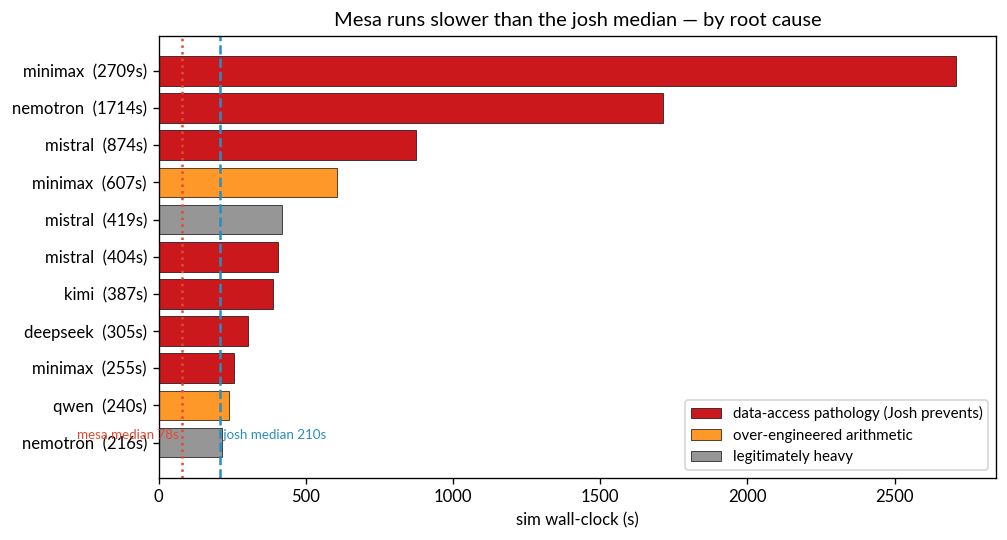


7/11 slow runs are data-access pathologies Josh's declarative binding structurally prevents.


In [14]:
rows = [
 ("minimax", 2709, "data-access"), ("nemotron",1714, "data-access"),
 ("mistral",  874, "data-access"), ("minimax",  607, "arithmetic"),
 ("mistral",  419, "heavy"),       ("mistral",  404, "data-access"),
 ("kimi",     387, "data-access"), ("deepseek", 305, "data-access"),
 ("minimax",  255, "data-access"), ("qwen",     240, "arithmetic"),
 ("nemotron", 216, "heavy"),
]
COLORS = {"data-access":"#cb181d", "arithmetic":"#fe9929", "heavy":"#969696"}
LABEL  = {"data-access":"data-access pathology (Josh prevents)",
          "arithmetic":"over-engineered arithmetic", "heavy":"legitimately heavy"}
rows = sorted(rows, key=lambda x: x[1])
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.barh(range(len(rows)), [s for _,s,_ in rows],
        color=[COLORS[b] for *_,b in rows], edgecolor="black", lw=.4)
ax.set_yticks(range(len(rows))); ax.set_yticklabels([f"{m}  ({s}s)" for m,s,_ in rows])
ax.axvline(MESA_MED, color="#e34a33", ls=":",  lw=1.5)
ax.axvline(JOSH_MED, color="#2b8cbe", ls="--", lw=1.5)
ax.text(MESA_MED, 0.05, f"mesa median {MESA_MED:.0f}s ", color="#e34a33", fontsize=8, ha="right", va="bottom")
ax.text(JOSH_MED, 0.05, f" josh median {JOSH_MED:.0f}s", color="#2b8cbe", fontsize=8, ha="left", va="bottom")
ax.set_xlabel("sim wall-clock (s)")
ax.set_title("Mesa runs slower than the josh median — by root cause")
import matplotlib.patches as mp
ax.legend([mp.Patch(color=c, ec="black", lw=.4) for c in COLORS.values()],
          [LABEL[k] for k in COLORS], loc="lower right", fontsize=9)
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/runtime_outliers.png", bbox_inches="tight")
fig.savefig(f"{OUT_DIR}/runtime_outliers.pdf", bbox_inches="tight"); plt.show()
print(f"\n{sum(b=='data-access' for *_,b in rows)}/11 slow runs are data-access pathologies "
      f"Josh's declarative binding structurally prevents.")

## Takeaway

| | |
|---|---|
| **Median** | Mesa 78 s vs Josh 210 s — Mesa is ~2.7× faster at this scale. |
| **Tail** | The mesa runs that beat Josh's worst case are **implementation pathologies**, not framework overhead — **7 of 11** re-read or re-scan the climate grid inside a per-patch / per-timestep loop. |
| **Why it matters** | This is exactly the footgun Josh's DSL removes: climate inputs are **bound declaratively**, so "read / rescan the grid every tick" is not an expressible program. The same constraint that makes the MCP arm feel limiting makes Josh's default runtime well-behaved. |

So the runtime story is **not** "Mesa is slow." It is: *unconstrained Python is
fast when written well and catastrophic when written badly, and Mesa gives an
agent every opportunity to write it badly; Josh's constraints make the bad
version unwritable.* The outliers strengthen the **constraint-as-a-feature**
argument, not a framework-speed one.